# Performance Analytics — Mutual Fund Analytics Platform
**Bluestock Fintech Capstone | Day 4**

Covers: Daily Returns, CAGR (1yr/3yr/5yr), Sharpe Ratio, Sortino Ratio,
Alpha & Beta (OLS), Maximum Drawdown, Fund Scorecard, Benchmark Comparison.

**Note on 5-year CAGR:** NAV history starts Jan 2022 (4.4 years of data).
5yr CAGR is computed over the full available window and labelled accordingly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

RAW     = "../data/raw"
REPORTS = "../reports"
import os; os.makedirs(REPORTS, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "font.size": 10})

# ── Load ───────────────────────────────────────────────────
nav   = pd.read_csv(f"{RAW}/02_nav_history.csv",      parse_dates=["date"])
perf  = pd.read_csv(f"{RAW}/07_scheme_performance.csv")
bench = pd.read_csv(f"{RAW}/10_benchmark_indices.csv", parse_dates=["date"])
fm    = pd.read_csv(f"{RAW}/01_fund_master.csv")

nav   = nav.sort_values(["amfi_code","date"]).reset_index(drop=True)
name_map = dict(zip(fm["amfi_code"], fm["scheme_name"].str.split(" - ").str[0]))
fh_map   = dict(zip(fm["amfi_code"], fm["fund_house"]))
cat_map  = dict(zip(fm["amfi_code"], fm["sub_category"]))

RF_ANNUAL = 0.065          # 6.5% RBI repo rate proxy
RF_DAILY  = RF_ANNUAL / 252

print(f"NAV   : {nav.shape}  |  {nav['amfi_code'].nunique()} schemes")
print(f"Bench : {bench.shape} | indices: {bench['index_name'].unique().tolist()}")
print(f"Date  : {nav['date'].min().date()} → {nav['date'].max().date()}")


NAV   : (46000, 3)  |  40 schemes
Bench : (8050, 3) | indices: ['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']
Date  : 2022-01-03 → 2026-05-29


---
## Task 1 — Daily Returns

`daily_return = (nav_t / nav_t-1) − 1`

Computed per scheme. Validated with distribution statistics.


In [2]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Validate distribution
returns_all = nav["daily_return"].dropna()
print("=== Daily Return Distribution (All 40 Schemes) ===")
print(f"  Count   : {len(returns_all):,}")
print(f"  Mean    : {returns_all.mean()*100:.4f}%")
print(f"  Std Dev : {returns_all.std()*100:.4f}%")
print(f"  Min     : {returns_all.min()*100:.4f}%")
print(f"  Max     : {returns_all.max()*100:.4f}%")
print(f"  Skew    : {returns_all.skew():.4f}  (near 0 = symmetric)")
print(f"  Kurtosis: {returns_all.kurt():.4f}  (>3 = fat tails)")
print(f"  % positive days: {(returns_all > 0).mean()*100:.1f}%")


=== Daily Return Distribution (All 40 Schemes) ===
  Count   : 45,960
  Mean    : 0.0631%
  Std Dev : 1.0290%
  Min     : -5.8102%
  Max     : 6.4713%
  Skew    : 0.0427  (near 0 = symmetric)
  Kurtosis: 1.3673  (>3 = fat tails)
  % positive days: 54.5%


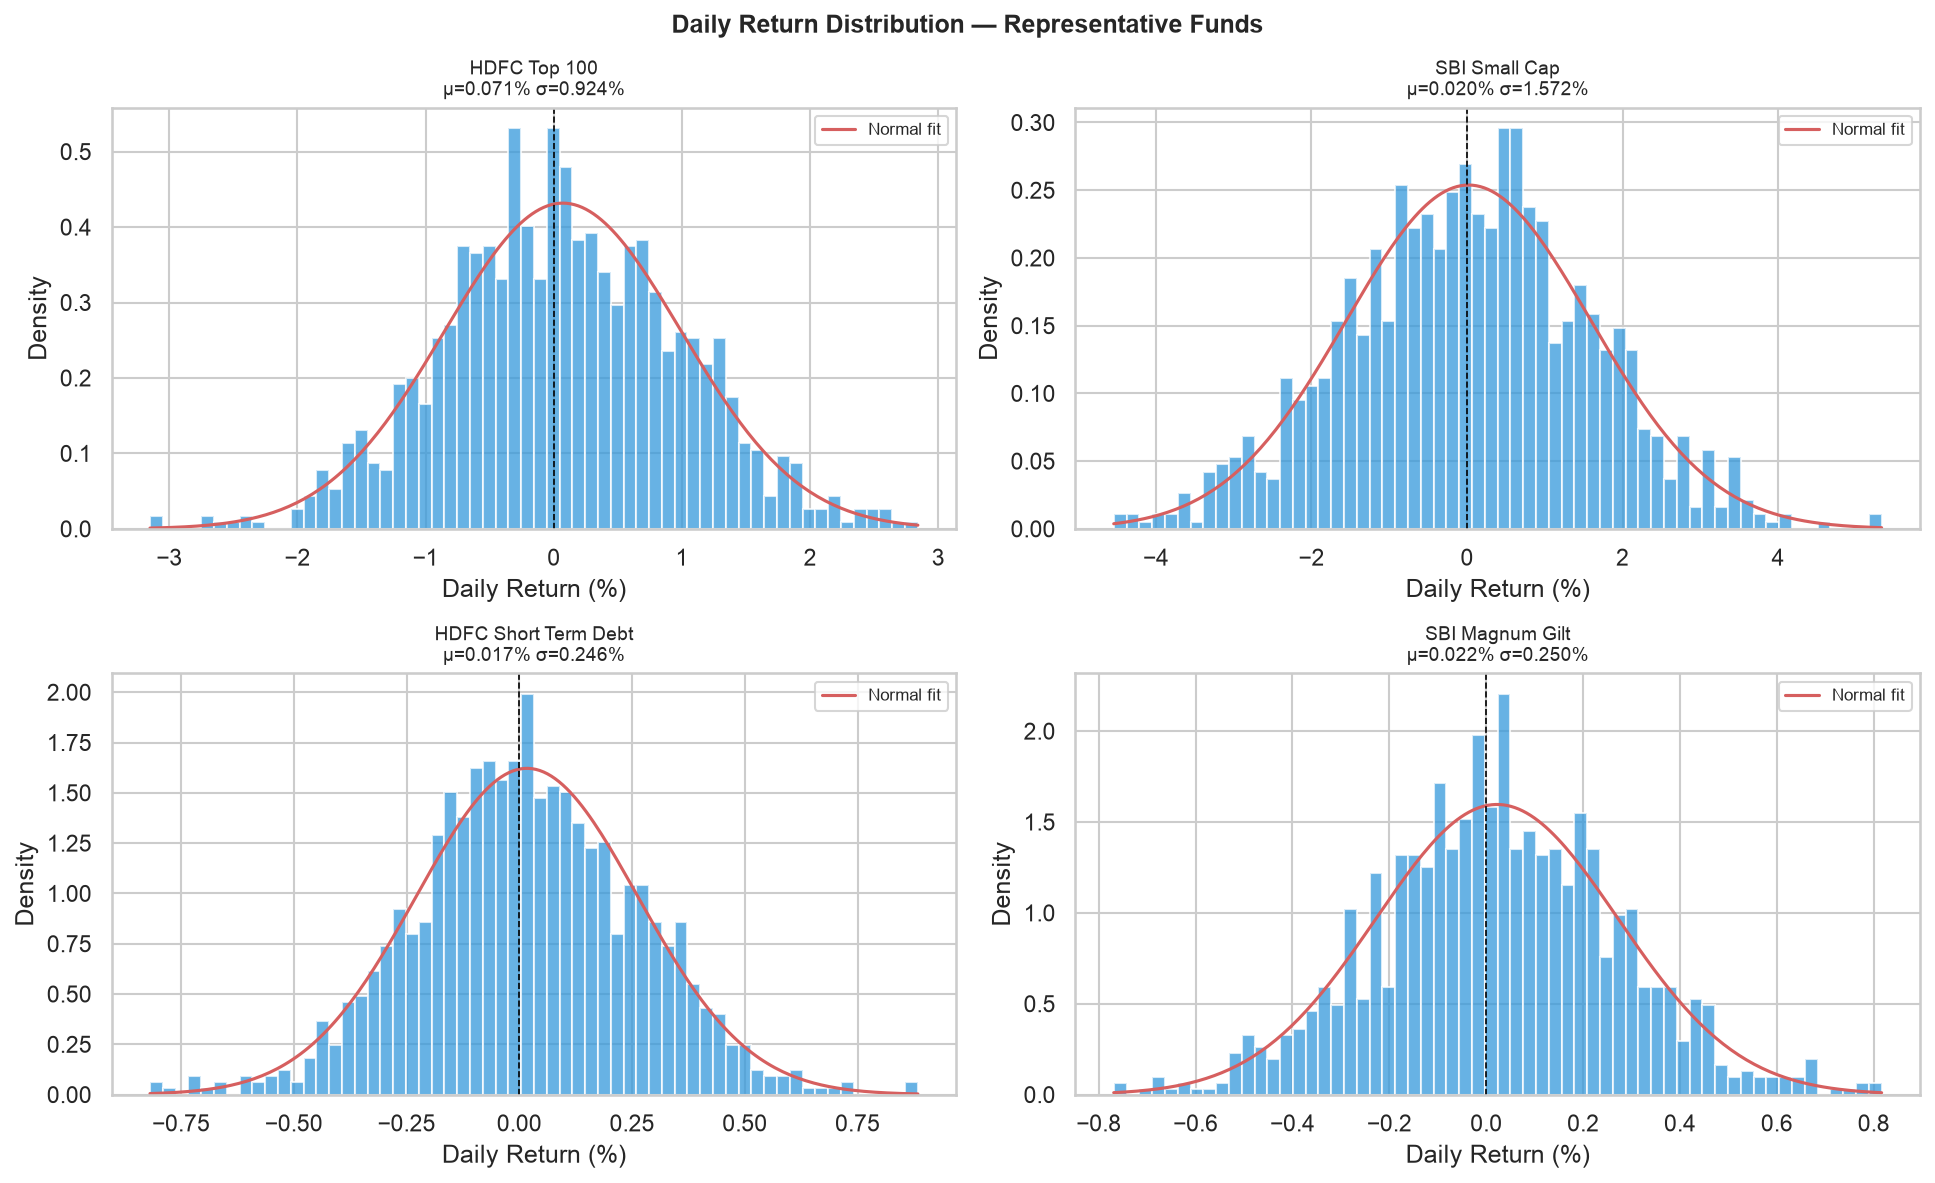

✓ Return distribution chart saved


In [3]:
# Return distribution histogram — 4 representative funds
SAMPLE_FUNDS = {
    125497: "HDFC Top 100",
    119599: "SBI Small Cap",
    100025: "HDFC Short Term Debt",
    119120: "SBI Magnum Gilt",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Daily Return Distribution — Representative Funds", fontsize=12, fontweight="bold")

for ax, (code, label) in zip(axes.flat, SAMPLE_FUNDS.items()):
    r = nav[nav["amfi_code"] == code]["daily_return"].dropna() * 100
    ax.hist(r, bins=60, color="#3498DB", alpha=0.75, edgecolor="white", density=True)
    # Overlay normal curve
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r-", linewidth=1.5, label="Normal fit")
    ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{label}\nμ={r.mean():.3f}% σ={r.std():.3f}%", fontsize=9)
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{REPORTS}/chart_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Return distribution chart saved")


---
## Task 2 — CAGR (1yr, 3yr, Full-Period)

`CAGR = (NAV_end / NAV_start) ^ (1/n) − 1`

where `n` = number of years in the period.
NAV data starts Jan 2022, so "5yr" uses the full 4.4-year window available.


In [4]:
end_date   = nav["date"].max()
start_1yr  = end_date - pd.DateOffset(years=1)
start_3yr  = end_date - pd.DateOffset(years=3)
start_full = nav["date"].min()   # Jan 2022

def nearest_nav(df, code, target_date):
    """Get NAV closest to target_date for a given scheme."""
    sub = df[df["amfi_code"] == code].sort_values("date")
    idx = (sub["date"] - target_date).abs().idxmin()
    return sub.loc[idx, "nav"], sub.loc[idx, "date"]

cagr_rows = []
for code in nav["amfi_code"].unique():
    grp = nav[nav["amfi_code"] == code].sort_values("date")
    nav_end  = grp["nav"].iloc[-1]
    date_end = grp["date"].iloc[-1]

    # 1yr
    nav_1yr, d_1yr = nearest_nav(grp, code, start_1yr)
    n_1yr = (date_end - d_1yr).days / 365.25
    cagr_1yr = (nav_end / nav_1yr) ** (1 / n_1yr) - 1

    # 3yr
    nav_3yr, d_3yr = nearest_nav(grp, code, start_3yr)
    n_3yr = (date_end - d_3yr).days / 365.25
    cagr_3yr = (nav_end / nav_3yr) ** (1 / n_3yr) - 1

    # Full period (since Jan 2022)
    nav_start = grp["nav"].iloc[0]
    date_start = grp["date"].iloc[0]
    n_full = (date_end - date_start).days / 365.25
    cagr_full = (nav_end / nav_start) ** (1 / n_full) - 1

    cagr_rows.append({
        "amfi_code"     : code,
        "scheme_name"   : name_map.get(code, str(code)),
        "sub_category"  : cat_map.get(code, ""),
        "cagr_1yr_pct"  : round(cagr_1yr  * 100, 2),
        "cagr_3yr_pct"  : round(cagr_3yr  * 100, 2),
        "cagr_full_pct" : round(cagr_full * 100, 2),
        "period_years"  : round(n_full, 1),
    })

cagr_df = pd.DataFrame(cagr_rows).sort_values("cagr_3yr_pct", ascending=False)

print("=== CAGR Comparison Table (sorted by 3yr CAGR) ===")
print(cagr_df[["scheme_name","sub_category","cagr_1yr_pct",
               "cagr_3yr_pct","cagr_full_pct"]].to_string(index=False))


=== CAGR Comparison Table (sorted by 3yr CAGR) ===
                       scheme_name    sub_category  cagr_1yr_pct  cagr_3yr_pct  cagr_full_pct
                  Axis Midcap Fund         Mid Cap         22.28         35.10          28.21
        Mirae Asset Large Cap Fund       Large Cap         20.38         33.99          30.97
           ICICI Pru Bluechip Fund       Large Cap         13.07         32.48          23.30
   HDFC Mid-Cap Opportunities Fund         Mid Cap         53.28         32.43          30.12
             ICICI Pru Midcap Fund         Mid Cap         29.63         31.77          32.83
                 SBI Bluechip Fund       Large Cap         60.49         30.45          25.80
               Kotak Flexicap Fund       Flexi Cap         26.68         29.58          30.91
        Mirae Asset Tax Saver Fund            ELSS         39.78         29.17          31.95
        ABSL Frontline Equity Fund       Large Cap         47.96         28.96          23.54
         

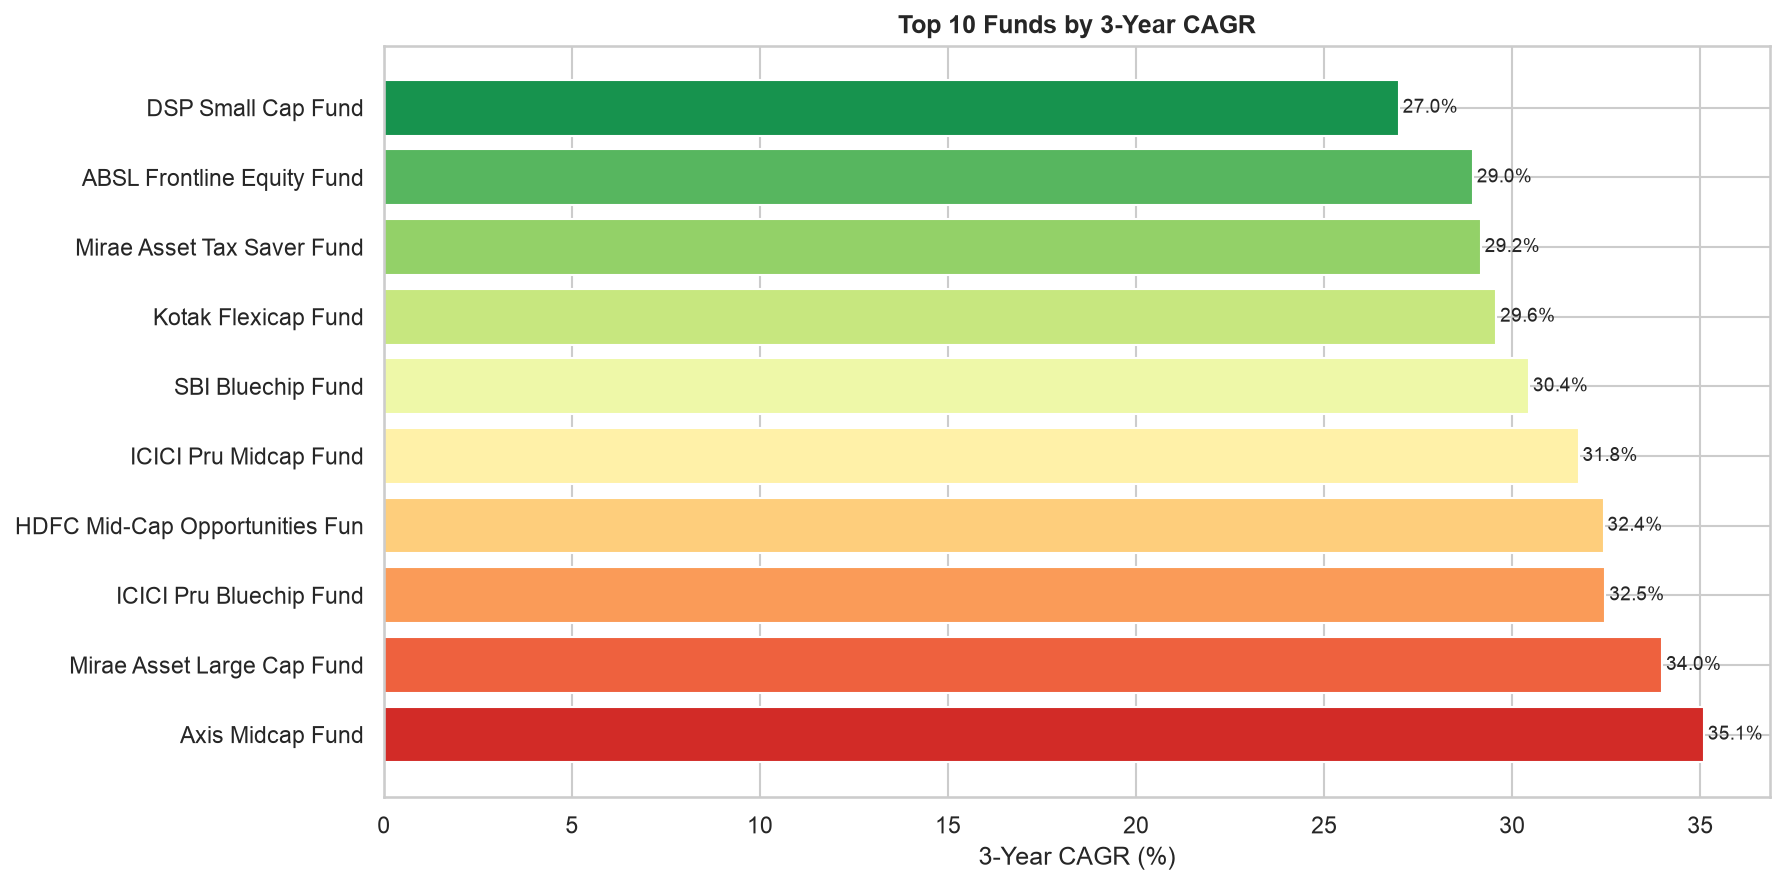

✓ CAGR chart saved


In [5]:
# Top 10 funds by 3yr CAGR — horizontal bar
top10 = cagr_df.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("RdYlGn_r", len(top10))[::-1]
bars = ax.barh(top10["scheme_name"].str[:30], top10["cagr_3yr_pct"],
               color=colors, edgecolor="white")
for bar, val in zip(bars, top10["cagr_3yr_pct"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.set_title("Top 10 Funds by 3-Year CAGR", fontsize=12, fontweight="bold")
ax.set_xlabel("3-Year CAGR (%)")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{REPORTS}/chart_cagr_top10.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ CAGR chart saved")


---
## Task 3 — Sharpe Ratio

`Sharpe = (Rp − Rf) / σp × √252`

- `Rp` = mean daily return of the fund
- `Rf` = 6.5% / 252 = daily risk-free rate (RBI repo rate proxy)
- `σp` = standard deviation of daily returns
- `× √252` = annualisation factor


In [6]:
sharpe_rows = []
for code, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    excess = r - RF_DAILY
    sharpe = (excess.mean() / r.std()) * np.sqrt(252)
    sharpe_rows.append({
        "amfi_code"    : code,
        "scheme_name"  : name_map.get(code, str(code)),
        "sub_category" : cat_map.get(code, ""),
        "mean_return"  : round(r.mean() * 252 * 100, 2),   # annualised %
        "std_dev_ann"  : round(r.std() * np.sqrt(252) * 100, 2),
        "sharpe_ratio" : round(sharpe, 4),
    })

sharpe_df = pd.DataFrame(sharpe_rows).sort_values("sharpe_ratio", ascending=False)
sharpe_df["sharpe_rank"] = range(1, len(sharpe_df) + 1)

print("=== Sharpe Ratio Ranking (All 40 Funds) ===")
print(sharpe_df[["sharpe_rank","scheme_name","sub_category",
                  "sharpe_ratio","mean_return","std_dev_ann"]].to_string(index=False))


=== Sharpe Ratio Ranking (All 40 Funds) ===
 sharpe_rank                        scheme_name    sub_category  sharpe_ratio  mean_return  std_dev_ann
           1         Mirae Asset Large Cap Fund       Large Cap        1.4483        27.06        14.19
           2                Kotak Flexicap Fund       Flexi Cap        1.3067        27.26        15.89
           3         Mirae Asset Tax Saver Fund            ELSS        1.2349        28.33        17.67
           4                  SBI Bluechip Fund       Large Cap        1.2083        23.10        13.74
           5              ICICI Pru Midcap Fund         Mid Cap        1.1801        29.27        19.29
           6                    DSP Midcap Fund         Mid Cap        1.1321        26.59        17.75
           7    HDFC Mid-Cap Opportunities Fund         Mid Cap        1.0937        27.21        18.94
           8        Nippon India Large Cap Fund       Large Cap        1.0817        21.80        14.15
           9        

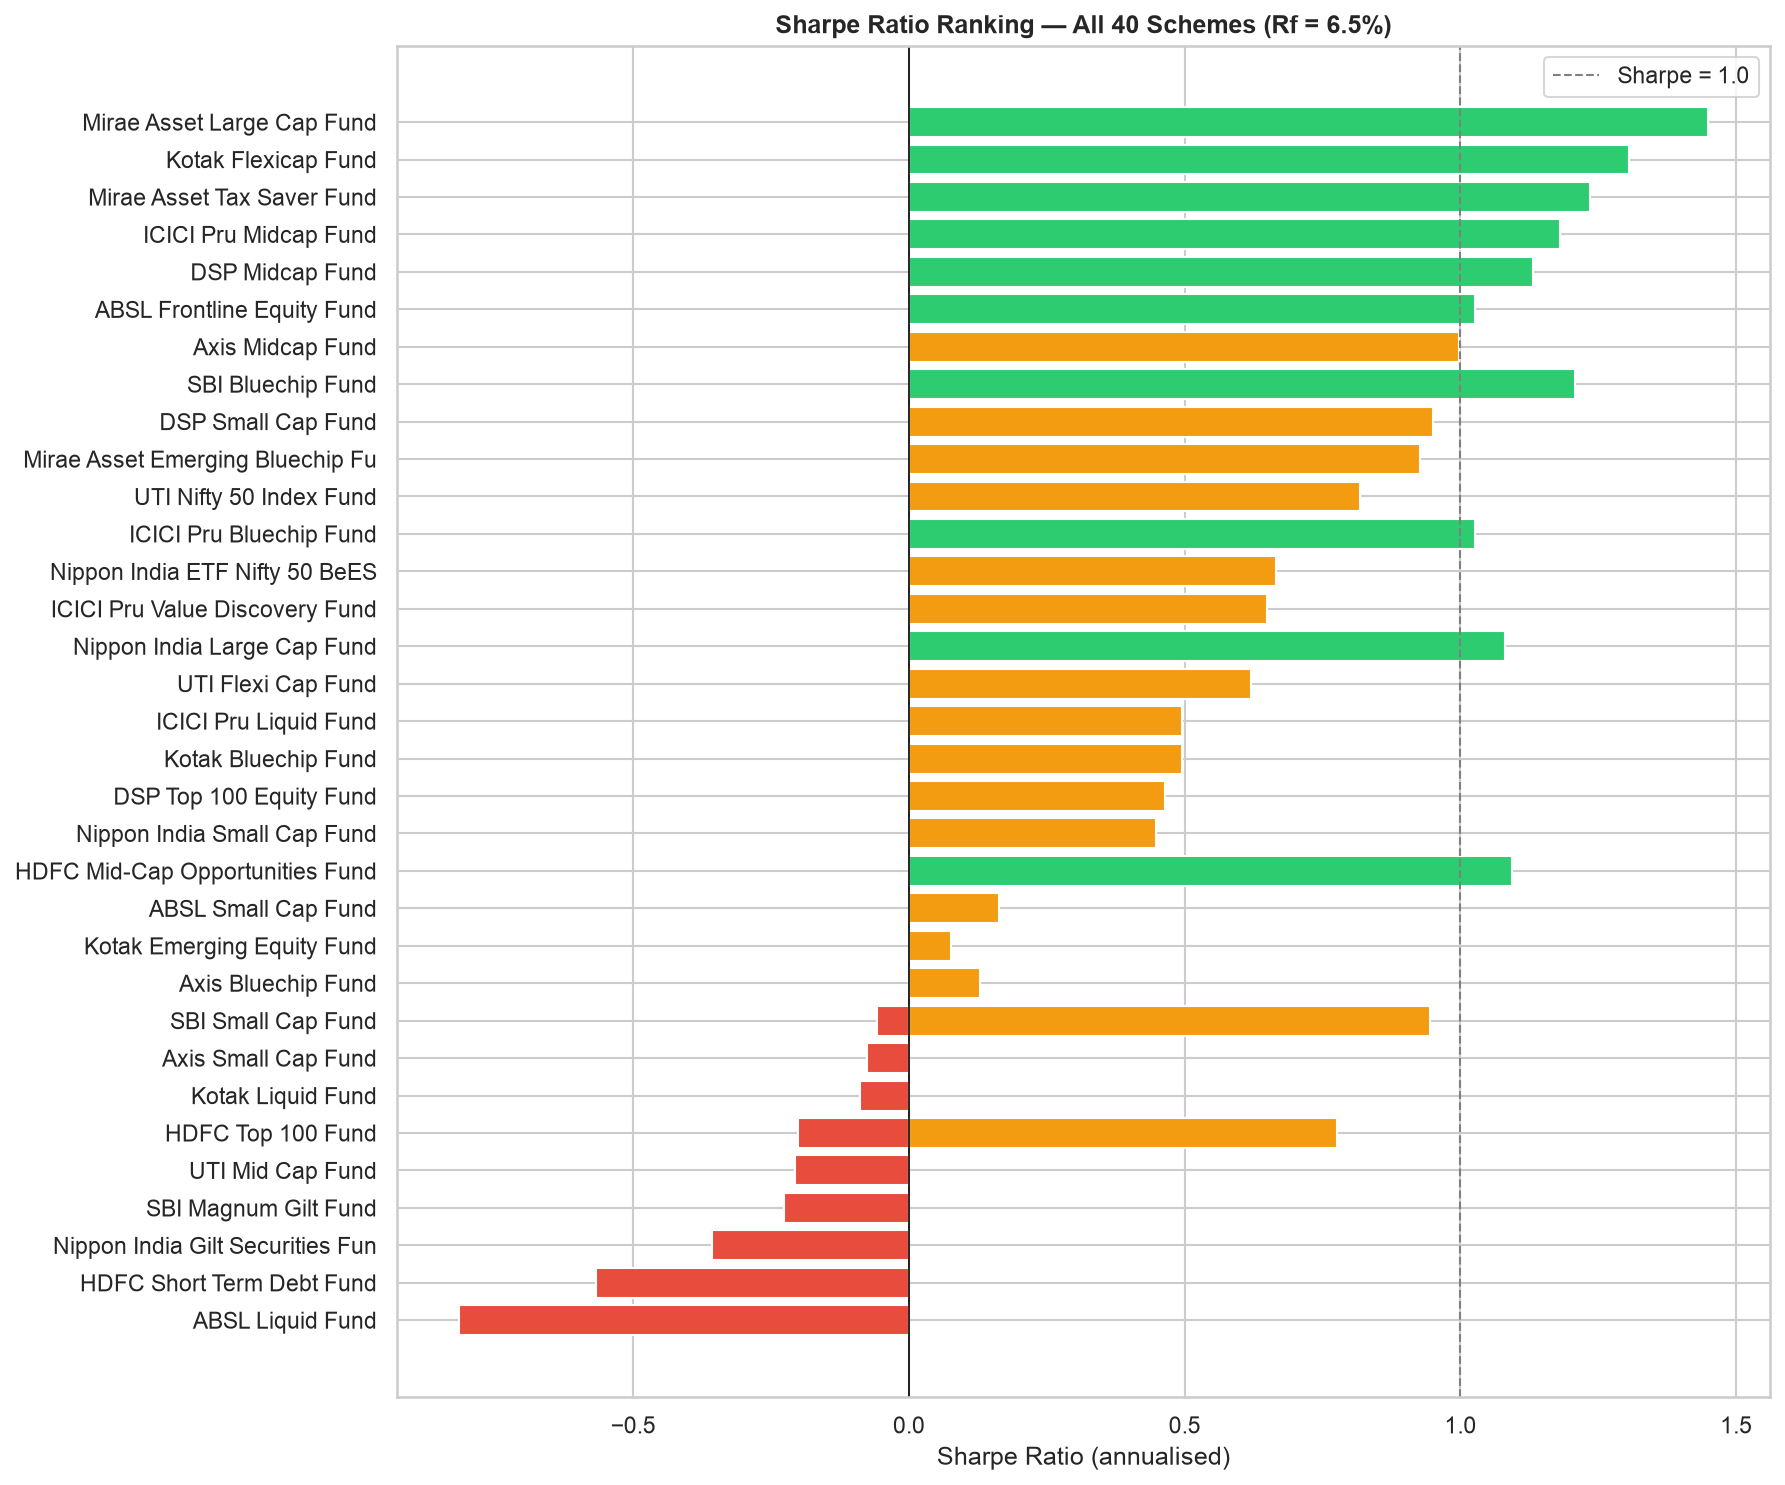

✓ Sharpe ranking chart saved


In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
palette = sharpe_df["sharpe_ratio"].apply(
    lambda x: "#E74C3C" if x < 0 else ("#F39C12" if x < 1 else "#2ECC71"))
bars = ax.barh(sharpe_df["scheme_name"].str[:32][::-1],
               sharpe_df["sharpe_ratio"][::-1],
               color=palette[::-1], edgecolor="white")
ax.axvline(x=1.0, color="gray", linestyle="--", linewidth=1, label="Sharpe = 1.0")
ax.axvline(x=0.0, color="black", linewidth=0.8)
ax.set_title("Sharpe Ratio Ranking — All 40 Schemes (Rf = 6.5%)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Sharpe Ratio (annualised)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS}/chart_sharpe_ranking.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Sharpe ranking chart saved")


---
## Task 4 — Sortino Ratio

`Sortino = (Rp − Rf) / σ_downside × √252`

`σ_downside` = standard deviation of **negative** daily returns only.
Penalises downside volatility without penalising upside.


In [8]:
sortino_rows = []
for code, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    excess     = r - RF_DAILY
    downside_r = r[r < 0]
    downside_std = downside_r.std() if len(downside_r) > 1 else np.nan
    sortino = (excess.mean() / downside_std) * np.sqrt(252) if downside_std else np.nan

    sortino_rows.append({
        "amfi_code"     : code,
        "scheme_name"   : name_map.get(code, str(code)),
        "sub_category"  : cat_map.get(code, ""),
        "sharpe_ratio"  : round((excess.mean() / r.std()) * np.sqrt(252), 4),
        "sortino_ratio" : round(sortino, 4),
        "downside_std"  : round(downside_std * np.sqrt(252) * 100, 2),
    })

sortino_df = pd.DataFrame(sortino_rows).sort_values("sortino_ratio", ascending=False)

print("=== Sortino vs Sharpe Comparison ===")
print(sortino_df[["scheme_name","sharpe_ratio","sortino_ratio","downside_std"]].to_string(index=False))


=== Sortino vs Sharpe Comparison ===
                       scheme_name  sharpe_ratio  sortino_ratio  downside_std
        Mirae Asset Large Cap Fund        1.4483         2.3856          8.62
               Kotak Flexicap Fund        1.3067         2.3643          8.78
        Mirae Asset Tax Saver Fund        1.2349         2.1469         10.17
                 SBI Bluechip Fund        1.2083         2.1403          7.76
             ICICI Pru Midcap Fund        1.1801         2.0294         11.22
                   DSP Midcap Fund        1.1321         1.8751         10.71
       Nippon India Large Cap Fund        1.0817         1.8501          8.27
   HDFC Mid-Cap Opportunities Fund        1.0937         1.8291         11.32
           ICICI Pru Bluechip Fund        1.0265         1.8053          8.17
        ABSL Frontline Equity Fund        1.0272         1.7996          8.32
                  Axis Midcap Fund        0.9982         1.7038         11.37
                SBI Small C

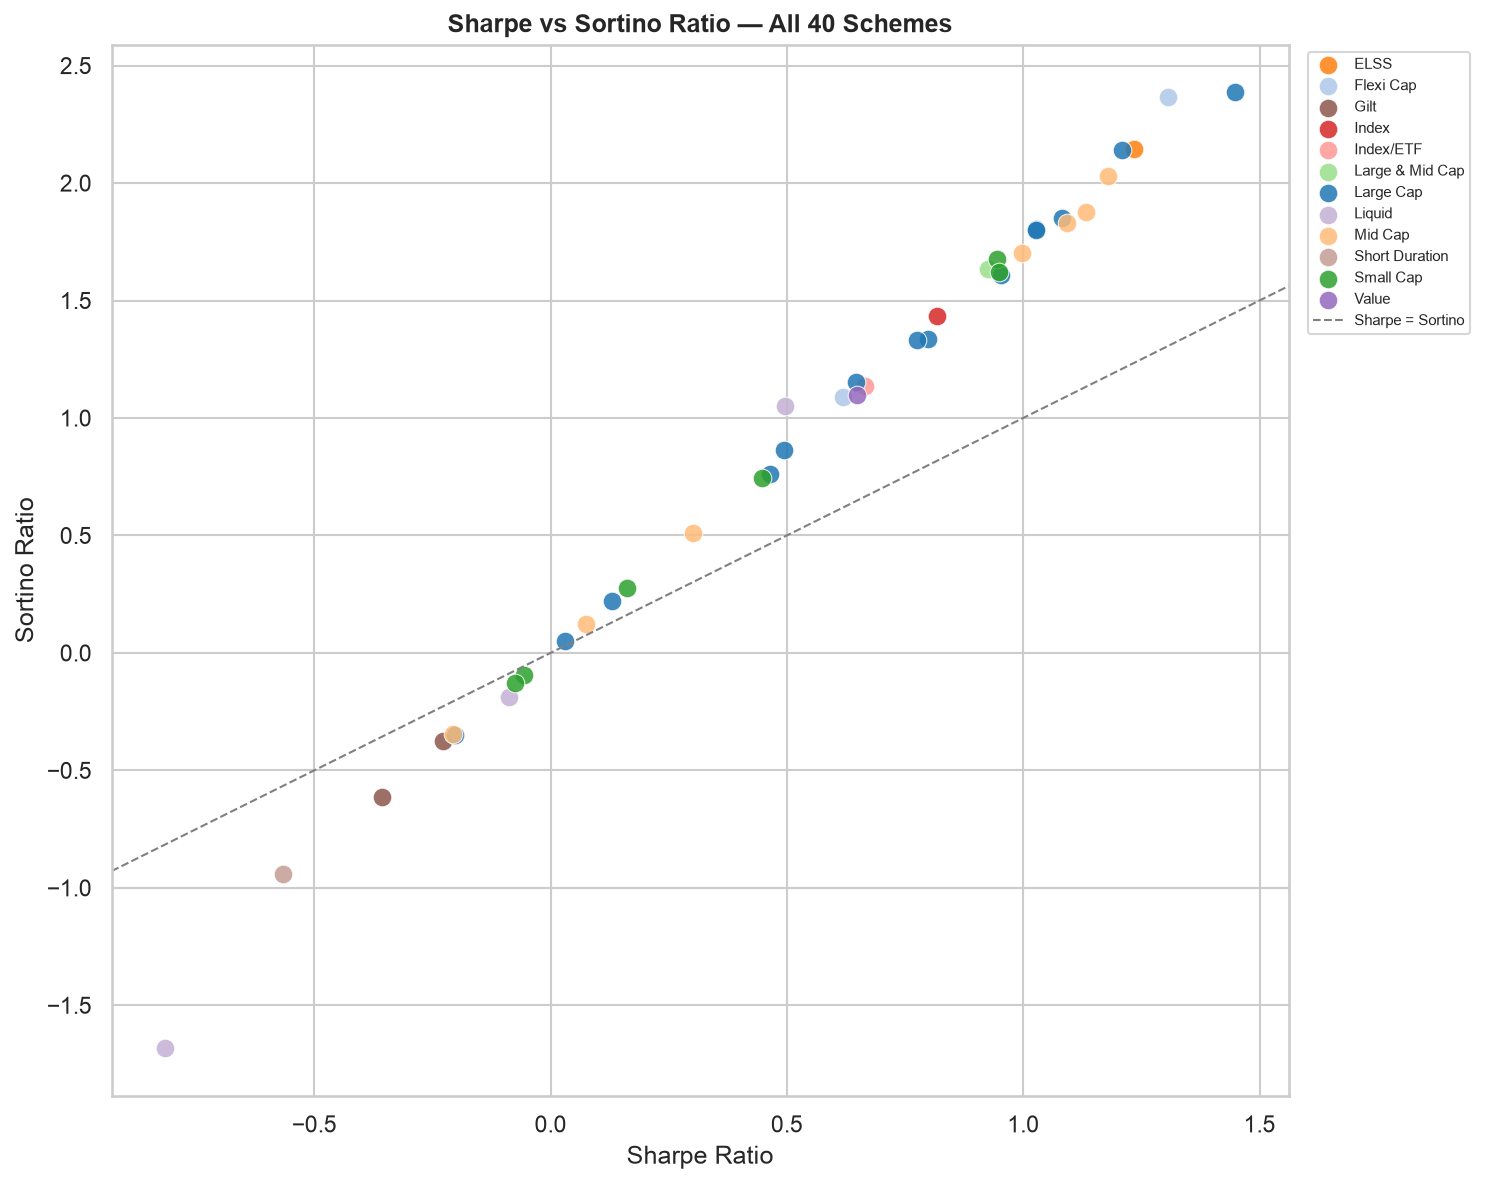

✓ Sharpe vs Sortino chart saved


In [9]:
# Sharpe vs Sortino scatter — coloured by sub_category
fig, ax = plt.subplots(figsize=(10, 8))
categories = sortino_df["sub_category"].unique()
palette    = dict(zip(categories, sns.color_palette("tab20", len(categories))))

for cat, grp in sortino_df.groupby("sub_category"):
    ax.scatter(grp["sharpe_ratio"], grp["sortino_ratio"],
               label=cat, color=palette.get(cat, "gray"),
               s=80, alpha=0.85, edgecolors="white", linewidths=0.5)

ax.axline((0,0), slope=1, color="gray", linestyle="--", linewidth=1, label="Sharpe = Sortino")
ax.set_title("Sharpe vs Sortino Ratio — All 40 Schemes", fontsize=12, fontweight="bold")
ax.set_xlabel("Sharpe Ratio")
ax.set_ylabel("Sortino Ratio")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(f"{REPORTS}/chart_sharpe_vs_sortino.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Sharpe vs Sortino chart saved")


---
## Task 5 — Alpha and Beta via OLS Regression

Regress each fund's daily returns on **Nifty 100** daily returns using
`scipy.stats.linregress`.

- **Beta** = slope (sensitivity to market)
- **Alpha** = intercept × 252 (annualised excess return vs market)
- **R²** = goodness of fit (how much variance explained by market)


In [10]:
# Build Nifty 100 daily returns series
nifty100 = (bench[bench["index_name"] == "NIFTY100"]
            .sort_values("date").set_index("date")["close_value"])
nifty100_ret = nifty100.pct_change().dropna()

ab_rows = []
for code, grp in nav.groupby("amfi_code"):
    fund_ret = grp.set_index("date")["daily_return"].dropna()

    # Align on common dates
    aligned = pd.concat([fund_ret, nifty100_ret], axis=1, join="inner")
    aligned.columns = ["fund", "market"]
    aligned = aligned.dropna()

    if len(aligned) < 50:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        aligned["market"], aligned["fund"]
    )

    ab_rows.append({
        "amfi_code"   : code,
        "scheme_name" : name_map.get(code, str(code)),
        "sub_category": cat_map.get(code, ""),
        "beta"        : round(slope, 4),
        "alpha_daily" : round(intercept, 6),
        "alpha_annual": round(intercept * 252 * 100, 4),  # annualised %
        "r_squared"   : round(r_value ** 2, 4),
        "p_value"     : round(p_value, 4),
        "n_obs"       : len(aligned),
    })

ab_df = pd.DataFrame(ab_rows).sort_values("alpha_annual", ascending=False)
ab_df.to_csv(f"{REPORTS}/alpha_beta.csv", index=False)

print("=== Alpha & Beta — All 40 Funds (sorted by Alpha) ===")
print(ab_df[["scheme_name","beta","alpha_annual","r_squared"]].to_string(index=False))
print(f"\n✓ alpha_beta.csv saved → reports/")


=== Alpha & Beta — All 40 Funds (sorted by Alpha) ===
                       scheme_name    beta  alpha_annual  r_squared
                SBI Small Cap Fund -0.0232       30.3370     0.0001
                DSP Small Cap Fund  0.0115       30.0579     0.0000
             ICICI Pru Midcap Fund  0.0005       29.2636     0.0000
        Mirae Asset Tax Saver Fund  0.0181       28.2704     0.0002
               Kotak Flexicap Fund -0.0228       27.3305     0.0003
   HDFC Mid-Cap Opportunities Fund  0.0051       27.1954     0.0000
        Mirae Asset Large Cap Fund  0.0237       26.9838     0.0005
                   DSP Midcap Fund -0.0025       26.5986     0.0000
                  Axis Midcap Fund -0.0663       26.0767     0.0019
                 SBI Bluechip Fund -0.0318       23.2010     0.0009
       Nippon India Large Cap Fund -0.0084       21.8294     0.0001
        ABSL Frontline Equity Fund  0.0211       21.3998     0.0003
           ICICI Pru Bluechip Fund  0.0162       21.1948     0

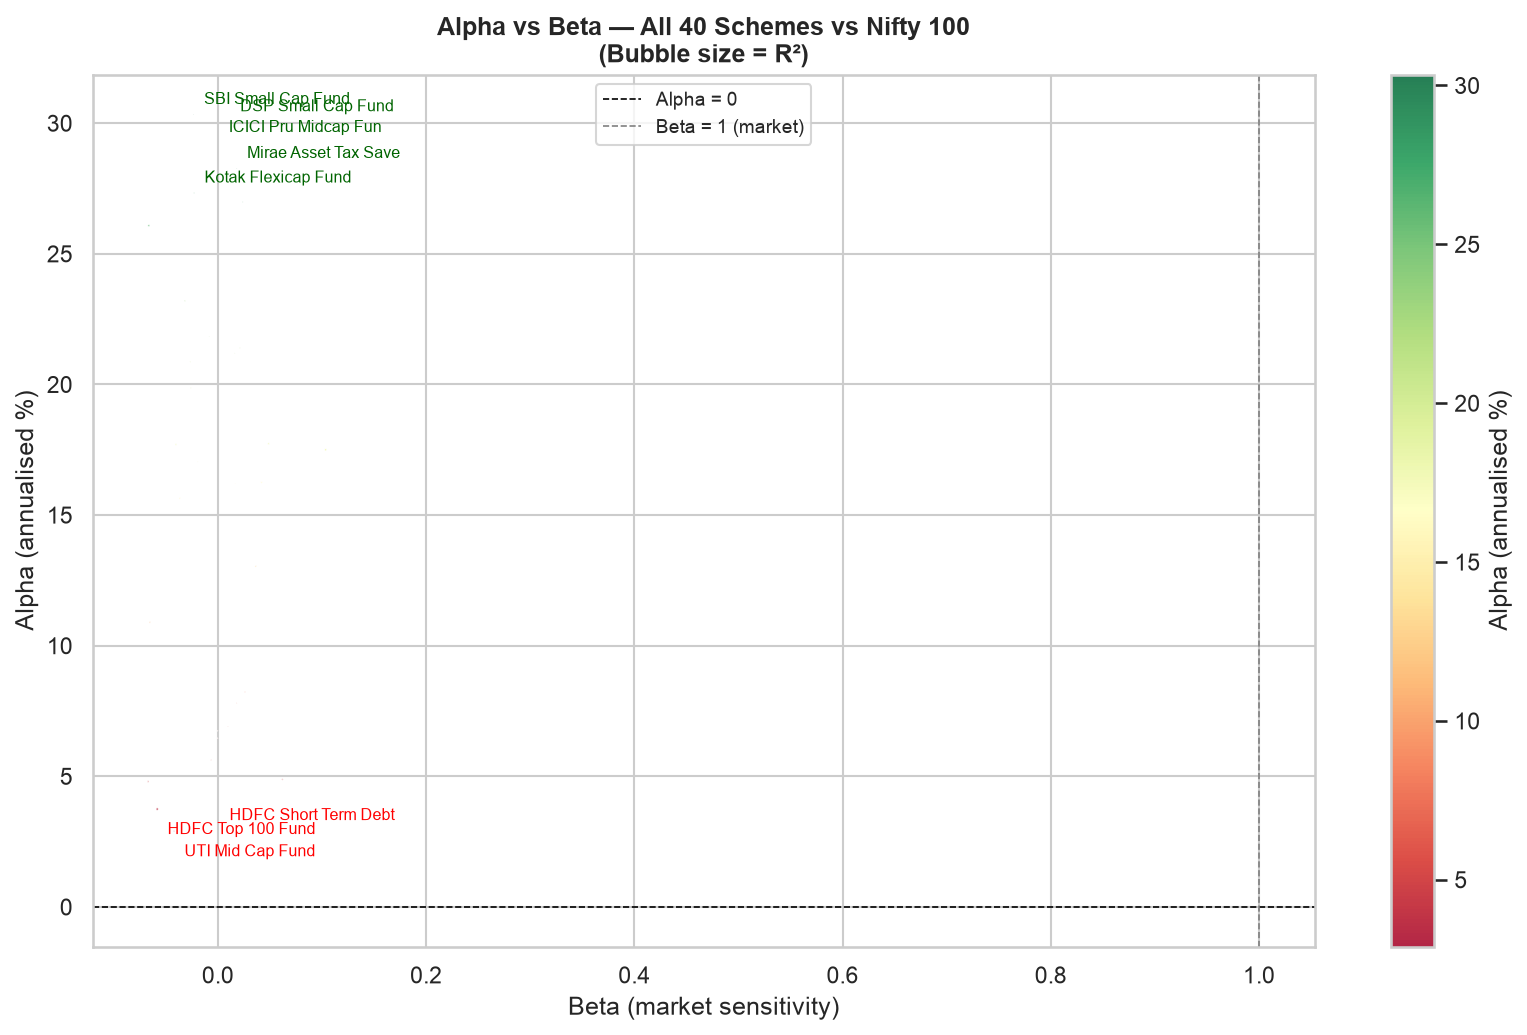

✓ Alpha/Beta chart saved


In [11]:
# Alpha vs Beta scatter — bubble size = R²
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    ab_df["beta"], ab_df["alpha_annual"],
    s=ab_df["r_squared"] * 500,
    c=ab_df["alpha_annual"],
    cmap="RdYlGn", alpha=0.85, edgecolors="white", linewidths=0.5
)
plt.colorbar(sc, ax=ax, label="Alpha (annualised %)")

# Annotate top 5 and bottom 3 by alpha
for _, row in ab_df.head(5).iterrows():
    ax.annotate(row["scheme_name"][:20],
        xy=(row["beta"], row["alpha_annual"]),
        xytext=(5, 5), textcoords="offset points", fontsize=7.5,
        color="darkgreen")
for _, row in ab_df.tail(3).iterrows():
    ax.annotate(row["scheme_name"][:20],
        xy=(row["beta"], row["alpha_annual"]),
        xytext=(5, -12), textcoords="offset points", fontsize=7.5,
        color="red")

ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--", label="Alpha = 0")
ax.axvline(x=1, color="gray",  linewidth=0.8, linestyle="--", label="Beta = 1 (market)")
ax.set_title("Alpha vs Beta — All 40 Schemes vs Nifty 100\n(Bubble size = R²)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Beta (market sensitivity)")
ax.set_ylabel("Alpha (annualised %)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{REPORTS}/chart_alpha_beta.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Alpha/Beta chart saved")


---
## Task 6 — Maximum Drawdown

`Drawdown = NAV / running_max(NAV) − 1`

`Max Drawdown = min(Drawdown)` — most negative value = worst loss from a peak.

Also captures the peak date (when loss started) and trough date (when it was worst).


In [12]:
dd_rows = []
for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date").copy()
    grp["running_max"] = grp["nav"].cummax()
    grp["drawdown"]    = grp["nav"] / grp["running_max"] - 1

    max_dd     = grp["drawdown"].min()
    trough_idx = grp["drawdown"].idxmin()
    trough_dt  = grp.loc[trough_idx, "date"]

    # Peak = last date where running_max == nav before the trough
    peak_df = grp[grp["date"] <= trough_dt]
    peak_idx = peak_df["nav"].idxmax()
    peak_dt  = grp.loc[peak_idx, "date"]

    # Recovery = first date after trough where nav >= running_max at trough
    peak_nav   = grp.loc[peak_idx, "nav"]
    recovery   = grp[(grp["date"] > trough_dt) & (grp["nav"] >= peak_nav)]
    recovery_dt = recovery["date"].iloc[0] if len(recovery) > 0 else None
    duration_days = (trough_dt - peak_dt).days

    dd_rows.append({
        "amfi_code"       : code,
        "scheme_name"     : name_map.get(code, str(code)),
        "sub_category"    : cat_map.get(code, ""),
        "max_drawdown_pct": round(max_dd * 100, 2),
        "peak_date"       : peak_dt.date(),
        "trough_date"     : trough_dt.date(),
        "duration_days"   : duration_days,
        "recovered"       : recovery_dt is not None,
    })

dd_df = pd.DataFrame(dd_rows).sort_values("max_drawdown_pct")

print("=== Maximum Drawdown — All 40 Funds ===")
print(dd_df[["scheme_name","max_drawdown_pct","peak_date",
             "trough_date","duration_days","recovered"]].to_string(index=False))


=== Maximum Drawdown — All 40 Funds ===
                       scheme_name  max_drawdown_pct  peak_date trough_date  duration_days  recovered
                SBI Small Cap Fund            -52.57 2023-01-17  2025-10-28           1015      False
               Axis Small Cap Fund            -51.68 2025-05-22  2026-05-11            354      False
               ABSL Small Cap Fund            -35.45 2024-11-21  2026-05-11            536      False
                DSP Small Cap Fund            -31.17 2024-05-03  2025-01-03            245       True
                SBI Small Cap Fund            -28.71 2024-08-28  2025-05-14            259       True
                  UTI Mid Cap Fund            -28.00 2025-01-07  2026-04-27            475      False
                 HDFC Top 100 Fund            -24.73 2022-03-30  2022-09-15            169       True
        Kotak Emerging Equity Fund            -24.00 2023-11-09  2024-10-17            343       True
       Nippon India Small Cap Fund        

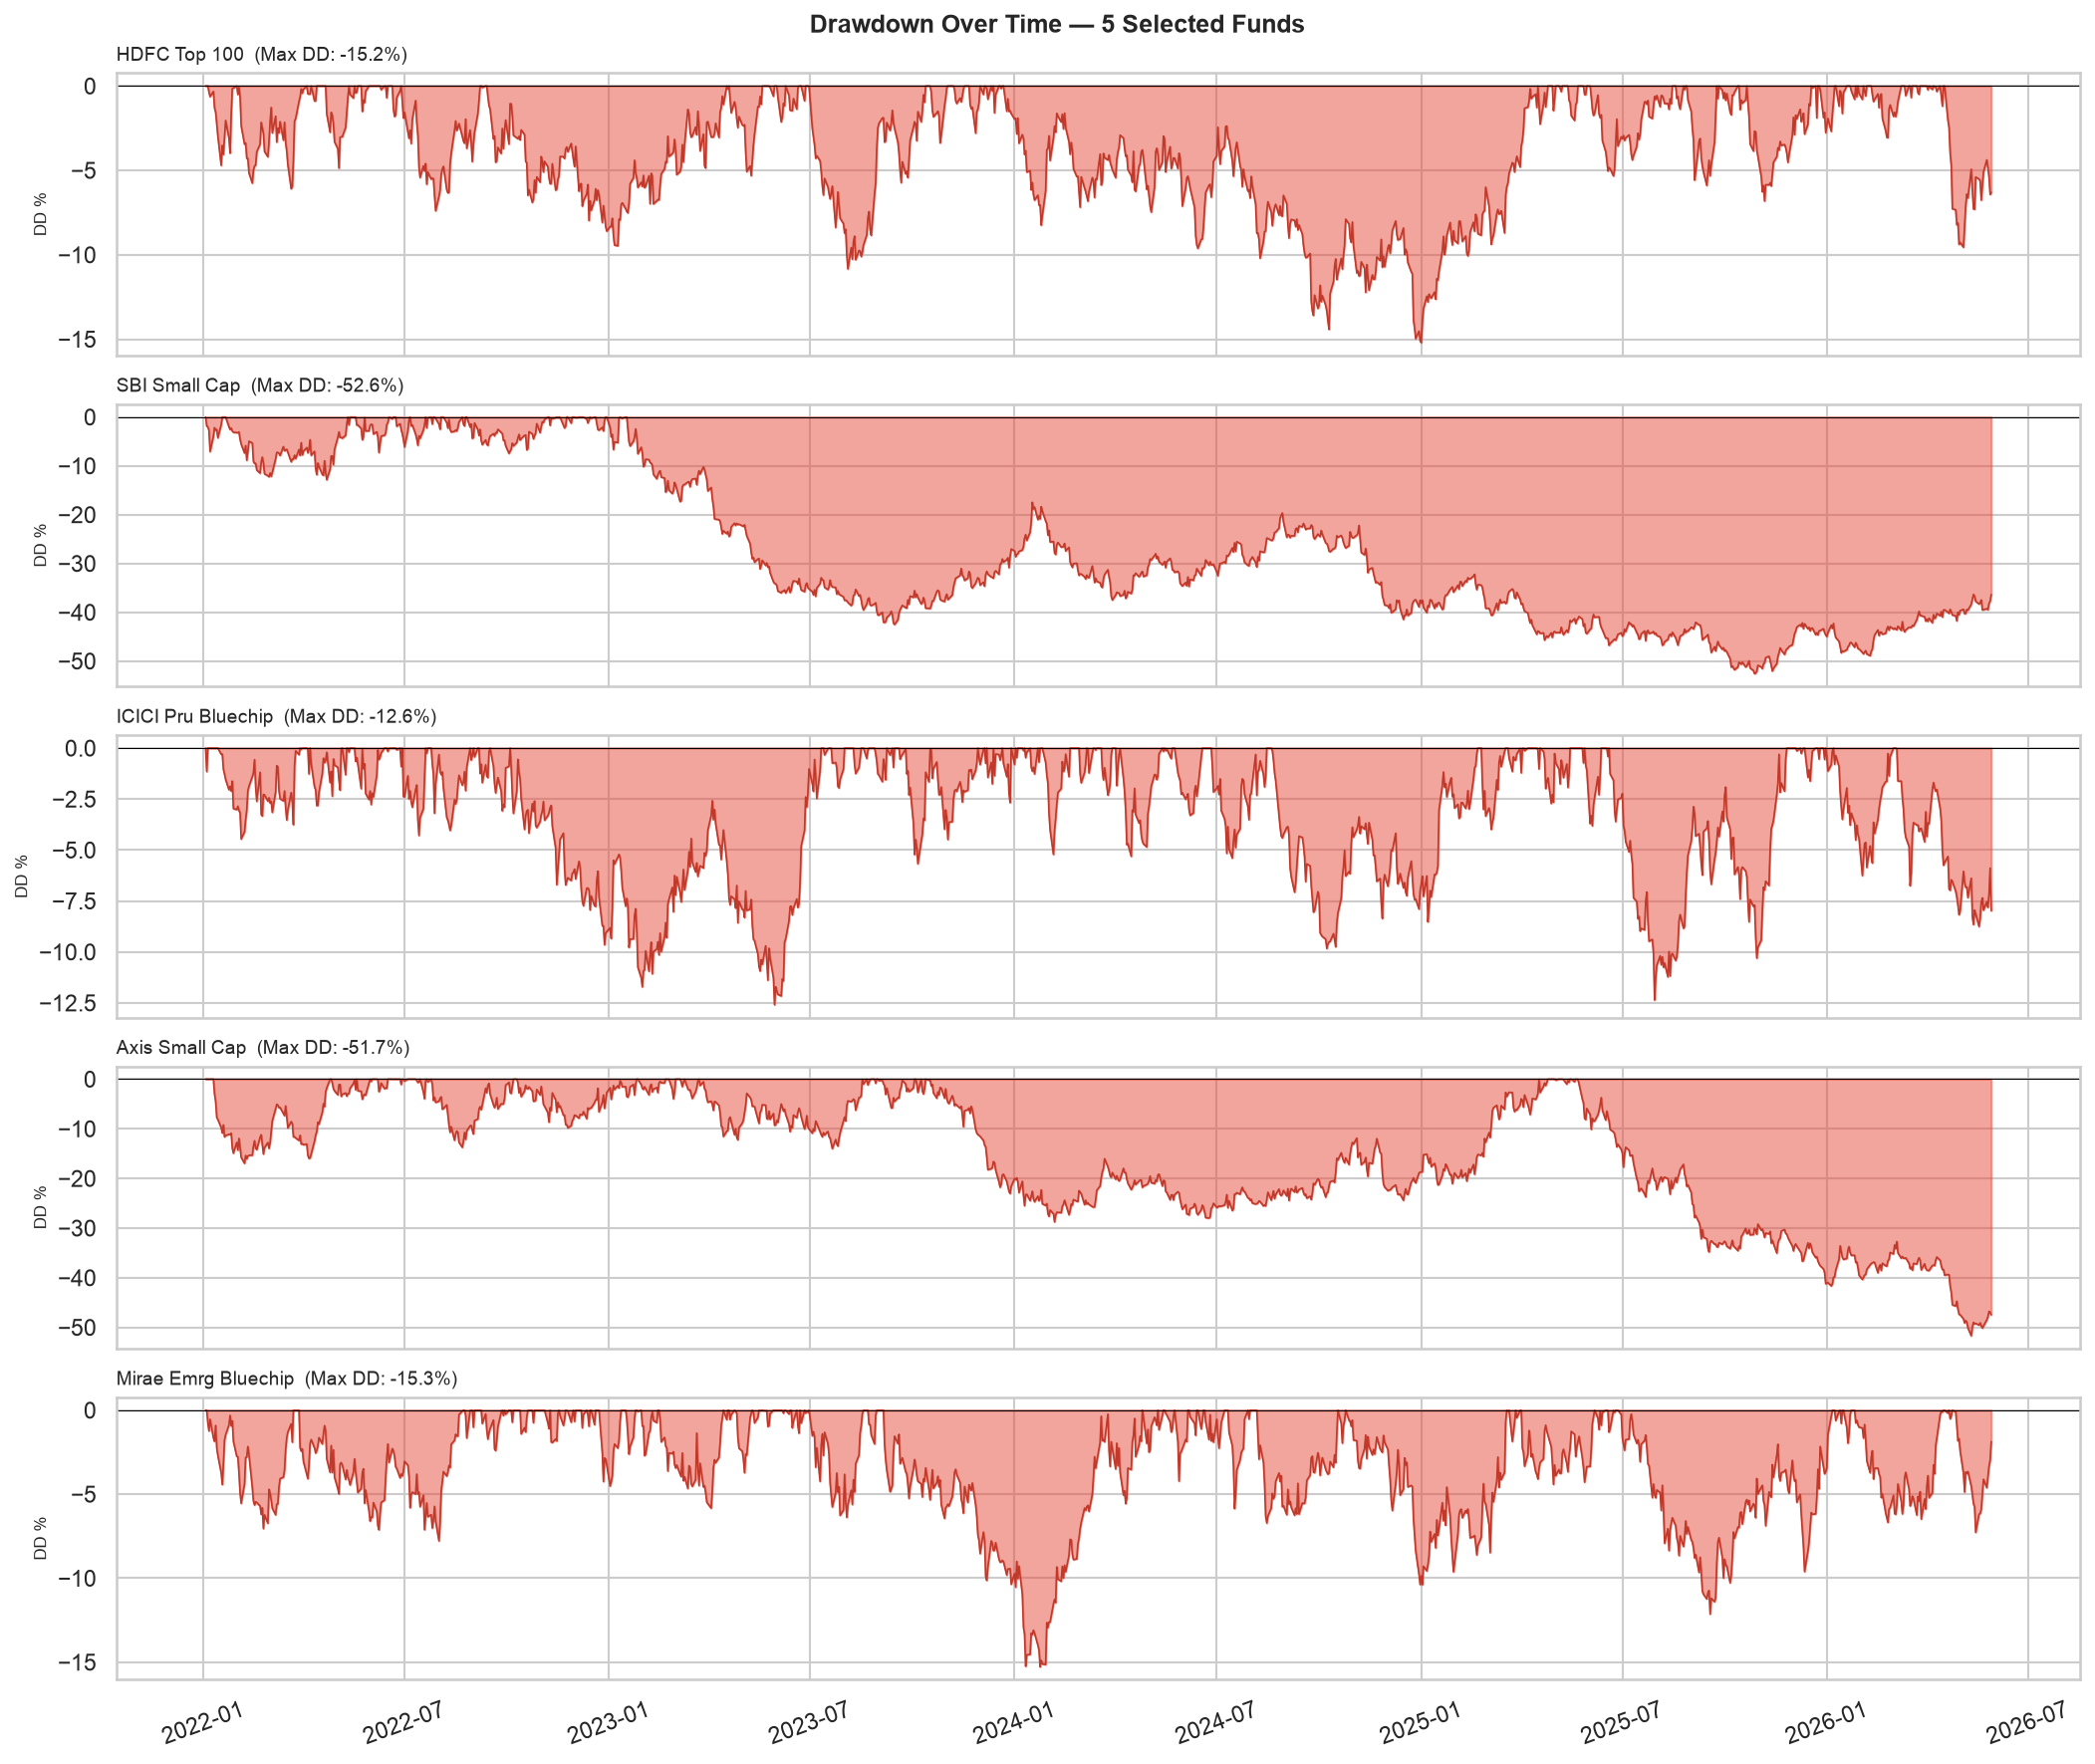

✓ Drawdown chart saved


In [13]:
# Drawdown chart for 5 equity funds + drawdown area
DRAW_FUNDS = {
    125497: "HDFC Top 100",
    119599: "SBI Small Cap",
    120504: "ICICI Pru Bluechip",
    119095: "Axis Small Cap",
    148568: "Mirae Emrg Bluechip",
}

fig, axes = plt.subplots(len(DRAW_FUNDS), 1, figsize=(14, 12), sharex=True)
fig.suptitle("Drawdown Over Time — 5 Selected Funds", fontsize=12, fontweight="bold")

for ax, (code, label) in zip(axes, DRAW_FUNDS.items()):
    grp = nav[nav["amfi_code"] == code].sort_values("date").copy()
    grp["running_max"] = grp["nav"].cummax()
    grp["drawdown"]    = (grp["nav"] / grp["running_max"] - 1) * 100
    ax.fill_between(grp["date"], grp["drawdown"], 0,
                    color="#E74C3C", alpha=0.5)
    ax.plot(grp["date"], grp["drawdown"], color="#C0392B", linewidth=0.8)
    ax.set_ylabel("DD %", fontsize=8)
    ax.set_title(f"{label}  (Max DD: {grp['drawdown'].min():.1f}%)",
                 fontsize=9, loc="left")
    ax.axhline(y=0, color="black", linewidth=0.5)

axes[-1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{REPORTS}/chart_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Drawdown chart saved")


---
## Task 7 — Fund Scorecard (0–100)

Composite score weighted as:

| Metric | Weight | Direction |
|---|---|---|
| 3yr CAGR rank | 30% | Higher return = higher rank |
| Sharpe ratio rank | 25% | Higher Sharpe = higher rank |
| Alpha rank | 20% | Higher alpha = higher rank |
| Expense ratio rank | 15% | **Inverse** — lower cost = higher rank |
| Max Drawdown rank | 10% | **Inverse** — smaller drawdown = higher rank |


In [14]:
# Assemble all metrics into one DataFrame
score_df = cagr_df[["amfi_code","scheme_name","sub_category","cagr_3yr_pct"]].copy()
score_df = score_df.merge(
    sharpe_df[["amfi_code","sharpe_ratio"]], on="amfi_code", how="left")
score_df = score_df.merge(
    ab_df[["amfi_code","alpha_annual"]], on="amfi_code", how="left")
score_df = score_df.merge(
    dd_df[["amfi_code","max_drawdown_pct"]], on="amfi_code", how="left")
score_df = score_df.merge(
    perf[["amfi_code","expense_ratio_pct"]], on="amfi_code", how="left")

n = len(score_df)

# Rank each metric (rank 1 = best for that metric)
score_df["rank_cagr"]    = score_df["cagr_3yr_pct"].rank(ascending=False)
score_df["rank_sharpe"]  = score_df["sharpe_ratio"].rank(ascending=False)
score_df["rank_alpha"]   = score_df["alpha_annual"].rank(ascending=False)
score_df["rank_expense"] = score_df["expense_ratio_pct"].rank(ascending=True)   # inverse: lower = better
score_df["rank_dd"]      = score_df["max_drawdown_pct"].rank(ascending=False)   # inverse: less negative = better

# Weighted composite rank score — convert rank to 0-100 (rank 1 = 100, rank n = 0)
def rank_to_score(rank_series, n):
    return ((n - rank_series) / (n - 1) * 100).round(2)

score_df["score_cagr"]    = rank_to_score(score_df["rank_cagr"],    n)
score_df["score_sharpe"]  = rank_to_score(score_df["rank_sharpe"],  n)
score_df["score_alpha"]   = rank_to_score(score_df["rank_alpha"],   n)
score_df["score_expense"] = rank_to_score(score_df["rank_expense"], n)
score_df["score_dd"]      = rank_to_score(score_df["rank_dd"],      n)

score_df["composite_score"] = (
    0.30 * score_df["score_cagr"]    +
    0.25 * score_df["score_sharpe"]  +
    0.20 * score_df["score_alpha"]   +
    0.15 * score_df["score_expense"] +
    0.10 * score_df["score_dd"]
).round(2)

score_df["overall_rank"] = score_df["composite_score"].rank(ascending=False).astype(int)
score_df = score_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

# Save
scorecard_out = score_df[[
    "overall_rank","amfi_code","scheme_name","sub_category",
    "composite_score","cagr_3yr_pct","sharpe_ratio",
    "alpha_annual","expense_ratio_pct","max_drawdown_pct"
]].copy()
scorecard_out.to_csv(f"{REPORTS}/fund_scorecard.csv", index=False)

print("=== FUND SCORECARD — TOP 20 ===")
print(scorecard_out.head(20).to_string(index=False))
print(f"\n✓ fund_scorecard.csv saved → reports/")


=== FUND SCORECARD — TOP 20 ===
 overall_rank  amfi_code                        scheme_name    sub_category  composite_score  cagr_3yr_pct  sharpe_ratio  alpha_annual  expense_ratio_pct  max_drawdown_pct
            1     148567         Mirae Asset Large Cap Fund       Large Cap            85.90         33.99        1.4483       26.9838               1.46            -11.27
            2     120505              ICICI Pru Midcap Fund         Mid Cap            81.79         31.77        1.1801       29.2636               1.36            -18.19
            3     120843                Kotak Flexicap Fund       Flexi Cap            81.54         29.58        1.3067       27.3305               1.45            -12.97
            4     100033    HDFC Mid-Cap Opportunities Fund         Mid Cap            80.26         32.43        1.0937       27.1954               1.38            -16.22
            5     120504            ICICI Pru Bluechip Fund       Large Cap            79.48         32.48  

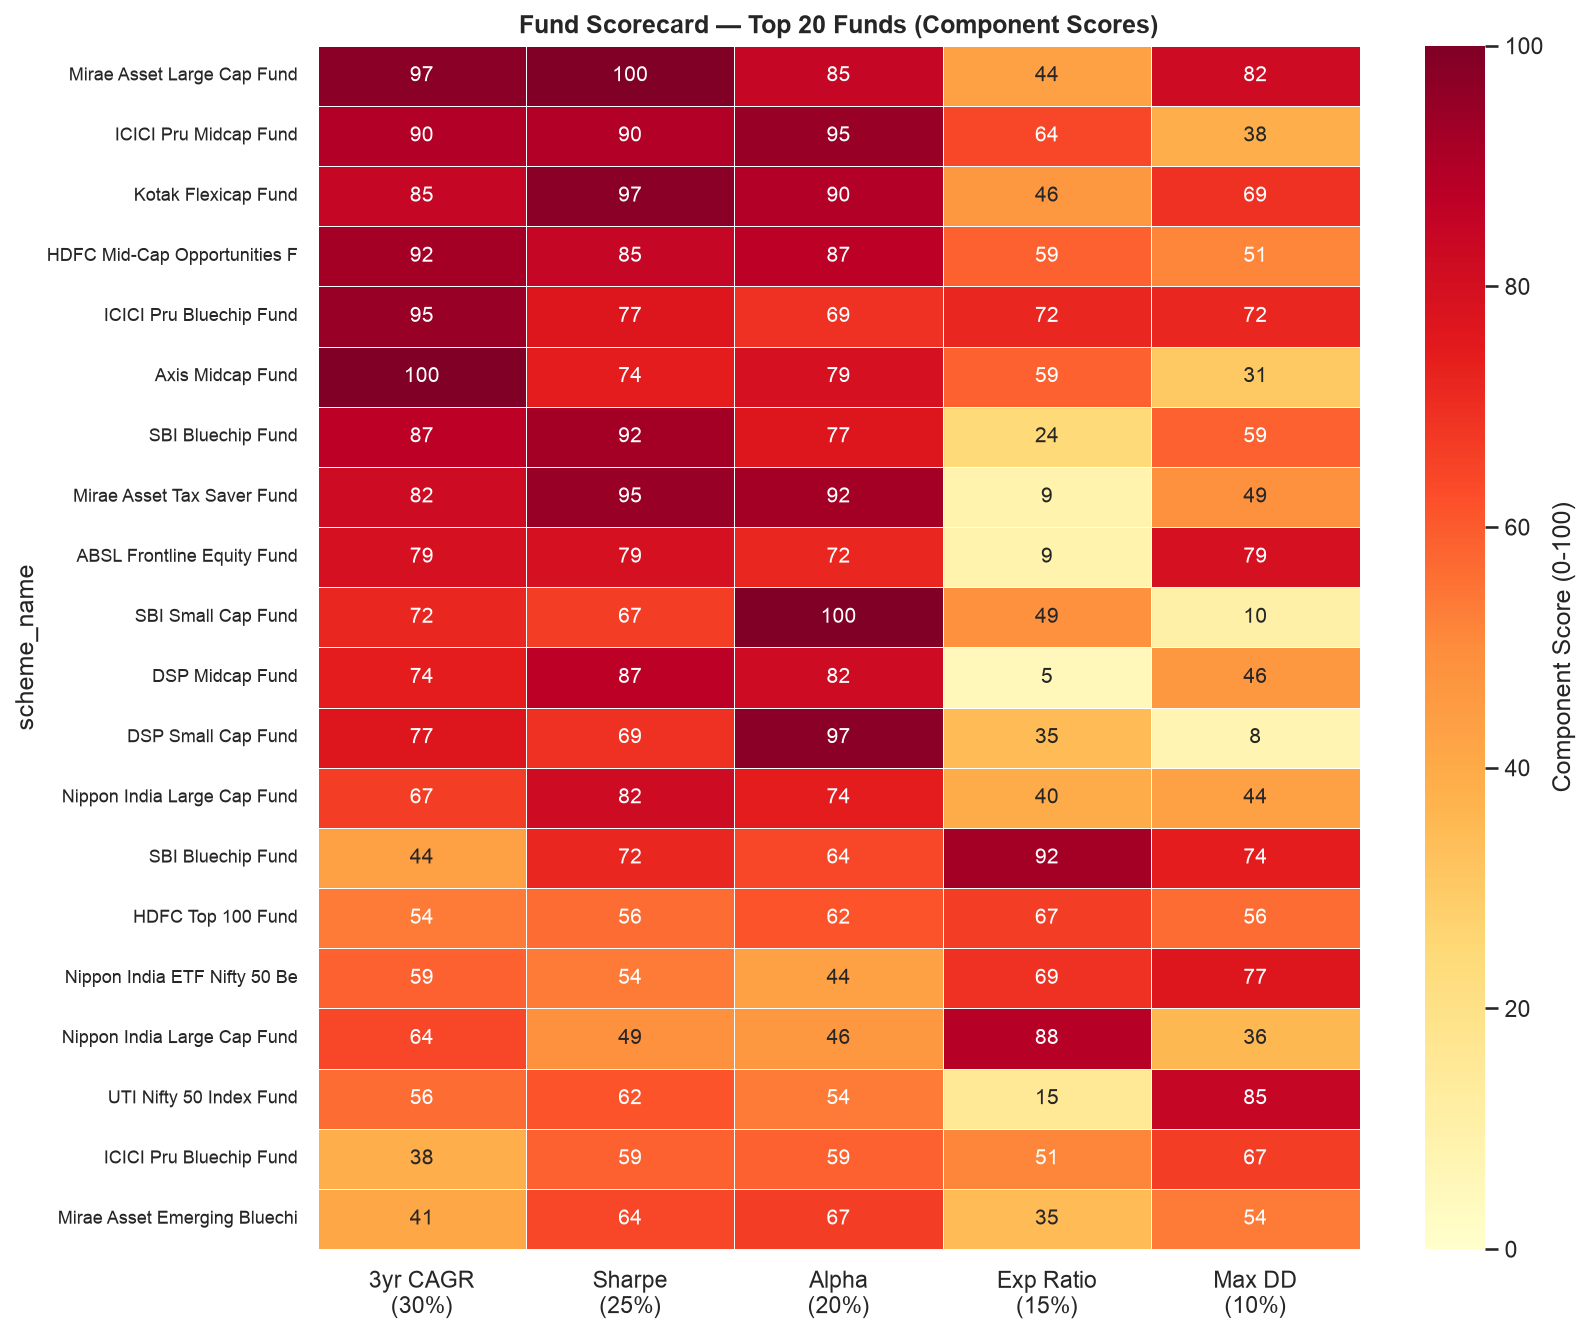

✓ Scorecard heatmap saved


In [15]:
# Scorecard heatmap — top 20 funds, all 5 component scores
top20 = score_df.head(20).set_index(score_df.head(20)["scheme_name"].str[:28])
heat_cols = ["score_cagr","score_sharpe","score_alpha","score_expense","score_dd"]
heat_labels = ["3yr CAGR\n(30%)", "Sharpe\n(25%)", "Alpha\n(20%)",
               "Exp Ratio\n(15%)", "Max DD\n(10%)"]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(top20[heat_cols], annot=True, fmt=".0f",
            cmap="YlOrRd", vmin=0, vmax=100,
            linewidths=0.4, linecolor="white",
            xticklabels=heat_labels, ax=ax,
            cbar_kws={"label": "Component Score (0-100)"})
ax.set_title("Fund Scorecard — Top 20 Funds (Component Scores)",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="y", labelsize=8.5)
plt.tight_layout()
plt.savefig(f"{REPORTS}/chart_scorecard_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Scorecard heatmap saved")


---
## Task 8 — Benchmark Comparison (Top 5 Funds vs Nifty 50 & Nifty 100)

3-year window. All series indexed to 100 at the start date for visual comparison.

`Tracking Error = std(fund_return − benchmark_return) × √252`


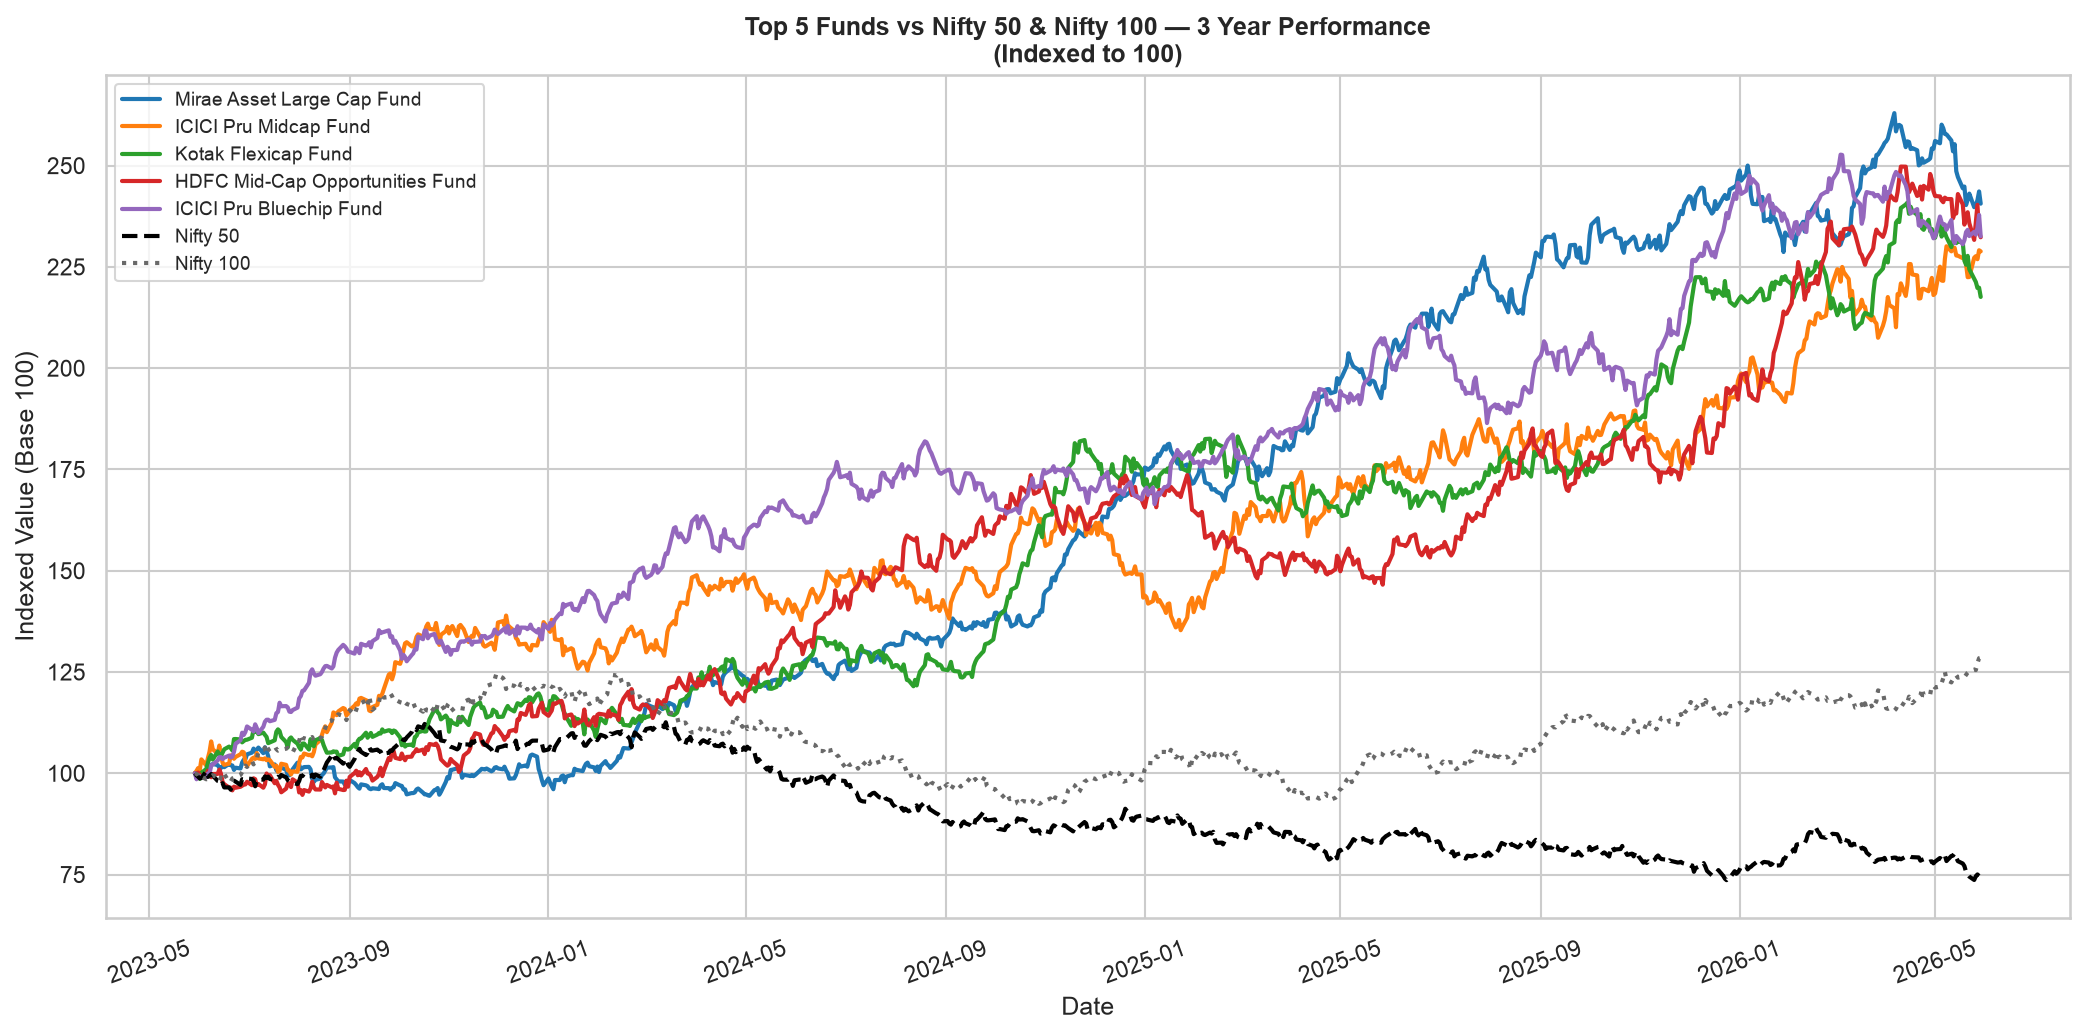

✓ Benchmark comparison chart saved → reports/benchmark_comparison_chart.png

=== Tracking Error vs Nifty 100 ===
                           fund  tracking_error_pct
     Mirae Asset Large Cap Fund               18.79
          ICICI Pru Midcap Fund               23.25
            Kotak Flexicap Fund               20.64
HDFC Mid-Cap Opportunities Fund               22.48
        ICICI Pru Bluechip Fund               18.73


In [16]:
# Top 5 funds from scorecard
top5_codes = score_df.head(5)["amfi_code"].tolist()
top5_names = {c: name_map.get(c, str(c)) for c in top5_codes}

# 3yr window
end_dt   = nav["date"].max()
start_dt = end_dt - pd.DateOffset(years=3)

# Benchmark returns
nifty50  = (bench[bench["index_name"] == "NIFTY50"]
            .sort_values("date").set_index("date")["close_value"])
nifty100 = (bench[bench["index_name"] == "NIFTY100"]
            .sort_values("date").set_index("date")["close_value"])

def index_to_100(series, start):
    s = series[series.index >= start].copy()
    return s / s.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]

te_rows = []
for (code, label), color in zip(top5_names.items(), colors):
    grp = nav[(nav["amfi_code"] == code) & (nav["date"] >= start_dt)].sort_values("date")
    nav_idx = grp.set_index("date")["nav"]
    nav_idx = nav_idx / nav_idx.iloc[0] * 100
    ax.plot(nav_idx.index, nav_idx.values, label=label, linewidth=2, color=color)

    # Tracking error vs Nifty 100
    fund_ret  = grp.set_index("date")["daily_return"].dropna()
    bench_ret = nifty100.pct_change().dropna()
    aligned   = pd.concat([fund_ret, bench_ret], axis=1, join="inner").dropna()
    aligned.columns = ["fund", "bench"]
    te = (aligned["fund"] - aligned["bench"]).std() * np.sqrt(252) * 100
    te_rows.append({"fund": label, "tracking_error_pct": round(te, 2)})

# Benchmarks
n50_idx  = index_to_100(nifty50,  start_dt)
n100_idx = index_to_100(nifty100, start_dt)
ax.plot(n50_idx.index,  n50_idx.values,  label="Nifty 50",  linewidth=2,
        color="black",  linestyle="--")
ax.plot(n100_idx.index, n100_idx.values, label="Nifty 100", linewidth=2,
        color="dimgray", linestyle=":")

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 — 3 Year Performance\n(Indexed to 100)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Value (Base 100)")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{REPORTS}/benchmark_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Benchmark comparison chart saved → reports/benchmark_comparison_chart.png")

te_df = pd.DataFrame(te_rows)
print("\n=== Tracking Error vs Nifty 100 ===")
print(te_df.to_string(index=False))


---
## Summary of Deliverables

| File | Description |
|---|---|
| `reports/fund_scorecard.csv` | Composite 0–100 score for all 40 funds |
| `reports/alpha_beta.csv` | OLS-derived Alpha and Beta vs Nifty 100 |
| `reports/benchmark_comparison_chart.png` | Top 5 funds vs Nifty 50 & 100 (3yr) |
| `reports/chart_return_distribution.png` | Daily return histograms |
| `reports/chart_cagr_top10.png` | Top 10 funds by 3yr CAGR |
| `reports/chart_sharpe_ranking.png` | All 40 funds ranked by Sharpe |
| `reports/chart_sharpe_vs_sortino.png` | Sharpe vs Sortino scatter |
| `reports/chart_alpha_beta.png` | Alpha vs Beta bubble chart |
| `reports/chart_drawdown.png` | Drawdown area charts — 5 funds |
| `reports/chart_scorecard_heatmap.png` | Scorecard component heatmap |


In [17]:
import os
outputs = [
    "fund_scorecard.csv", "alpha_beta.csv",
    "benchmark_comparison_chart.png",
    "chart_return_distribution.png", "chart_cagr_top10.png",
    "chart_sharpe_ranking.png", "chart_sharpe_vs_sortino.png",
    "chart_alpha_beta.png", "chart_drawdown.png",
    "chart_scorecard_heatmap.png",
]
print("=== OUTPUT STATUS ===")
for f in outputs:
    path = f"../reports/{f}"
    status = "✓" if os.path.exists(path) else "⚠ missing"
    print(f"  {status}  {f}")


=== OUTPUT STATUS ===
  ✓  fund_scorecard.csv
  ✓  alpha_beta.csv
  ✓  benchmark_comparison_chart.png
  ✓  chart_return_distribution.png
  ✓  chart_cagr_top10.png
  ✓  chart_sharpe_ranking.png
  ✓  chart_sharpe_vs_sortino.png
  ✓  chart_alpha_beta.png
  ✓  chart_drawdown.png
  ✓  chart_scorecard_heatmap.png
